# Chapter 25 - Computer Vision

*In which we connect the computer to the raw, unwashed world through the eyes of a camera.* - Peter Norvig,Stuart Russell in Artificial Intelligence: A Modern Approach

![Illusion](https://upload.wikimedia.org/wikipedia/commons/thumb/b/be/Checker_shadow_illusion.svg/1280px-Checker_shadow_illusion.svg.png)

## **The Importance of Vision**  
- **Biological Costs and Benefits** : Eyes occupy significant space, consume energy, and are delicate, but their ability to provide critical information justifies their biological cost.
- **Functional Advantages** : Vision enables agents to predict future interactions with their environment, such as obstacles to avoid, determining when to engage or retreat from threats, assessing terrain, and judging distances to objects.
- **Information Processing** : This chapter focuses on extracting valuable information from the vast data provided by biological eyes and cameras, highlighting the translation of visual data into actionable insights.

## **25.1 Introduction**  
- **Vision as a Perceptual Channel** : Vision is described as a channel through which stimuli are received and interpreted to form a representation of the world. Most vision relies on passive sensing, where no signal emission is necessary, unlike active sensing used by some animals and robots.
- **Active vs. Passive Sensing** : Active sensing involves emitting signals (like light, sound, or radar) and detecting their reflections. Examples include bats and dolphins using ultrasound and some robots using radar.
- **Feature Extraction** : Vision processes involve extracting features from images, which are simple computations yielding essential information. This can directly influence actions, such as an animal's steering response based on time-to-contact estimates with obstacles.
- **Model-Based Vision Approaches** : These include object models (from precise CAD designs to general object properties) and rendering models that describe how visual stimuli are produced. Despite sophisticated models, visual stimuli often remain ambiguous (e.g., distinguishing a white object under low light from a black object under intense light).
- **Handling Ambiguities** : Ambiguities in vision are managed by prioritizing likely interpretations or disregarding insignificant differences. For example, distant objects might be indistinct but do not affect immediate actions.
- **Core Problems in Computer Vision** :
- **Reconstruction** : Building a model of the world from images, which can involve creating geometric models or mapping surface textures.
- **Recognition** : Differentiating among objects based on visual and other data, which can include identifying objects, their states, and their characteristics.
- **Research and Development** : The last thirty years have seen significant advances in tools and methods for solving vision-related problems, driven by deeper understanding of image formation processes.


## **25.2 Image Formation**  

![pisa](https://upload.wikimedia.org/wikipedia/commons/thumb/4/4b/Italy_-_Pisa_-_Leaning_Tower.jpg/250px-Italy_-_Pisa_-_Leaning_Tower.jpg)

- **Distortion in Imaging** : Images can distort the true appearance of objects. For example, railway tracks in a photo may appear to converge in the distance, and small objects like a hand can block much larger objects like the moon when held close to the eye.
- **Examples of Visual Distortions** :
- Objects appear to shrink or grow when moved closer to or farther from the eye or when their orientation changes, a phenomenon known as foreshortening.
- **Importance of Modeling Visual Effects** : Understanding and modeling these visual distortions are crucial for developing effective object recognition systems and for reconstructing geometric forms from visual data. These models help interpret how objects are positioned and shaped in real space despite their distorted appearance in images.

### **25.2.1 Images without Lenses: The Pinhole Camera**  
- **Image Sensor Functionality** : Image sensors in eyes and cameras gather light to create a 2D image. Human eyes use rods (sensitive to a broad light spectrum) and cones (key for color vision), while cameras use sensors coated with materials like silver halides (film cameras) or pixel grids (digital cameras).
- **Sensor Mechanics** : In digital cameras, each pixel on the sensor, which could be a CCD or CMOS, detects light photons to produce an electrical signal. This process results in a cumulative output representing the average light intensity over specific periods and areas.
- **Pinhole Camera Basics** : A pinhole camera, consisting of a simple aperture and an image plane, focuses light from a single point on an object directly onto the sensor, ensuring a focused image. The pinhole size affects the clarity and focus of the resulting image.
![Pinhole Camera](https://upload.wikimedia.org/wikipedia/commons/thumb/3/3b/Pinhole-camera.svg/330px-Pinhole-camera.svg.png)
- **Motion Blur and Time Window Manipulation** : The image remains focused if the object is stationary or moves minimally during the sensor's exposure time. Movement beyond this causes motion blur, which can be controlled by adjusting the aperture’s open time.
![Motion Blur](https://upload.wikimedia.org/wikipedia/commons/thumb/2/24/Gorskii_03966u.jpg/960px-Gorskii_03966u.jpg)
- **Perspective Projection and Geometric Effects** : The pinhole camera model helps explain the principles of perspective projection, where the image formation process depends on distances and angles relative to the pinhole. This setup causes images to invert and distant objects to appear smaller. Parallel lines in the real world converge at a vanishing point in the image, demonstrating classic perspective effects seen in photographs.
- **Mathematical Representation** : The relationship between the coordinates of a point in the scene and its projection on the image plane can be expressed using ratios derived from similar triangles formed by the pinhole, object, and image plane. This explains why images of distant objects shrink and why images are inverted.

### Google: people looking at pisa tower



### **25.2.2 Lens Systems**  
- **Limitations of Pinhole Cameras** : Although pinhole cameras can focus light effectively, their small aperture allows only minimal light entry, resulting in dark images with graininess in film or noise in digital outputs due to low light levels and high random fluctuations.
- **Aperture Enlargement** : Increasing the aperture size brightens the image by capturing more light but also introduces defocus because the light at any point on the image plane comes from multiple points in the scene.
- **Use of Lens Systems** : To overcome these limitations, vertebrate eyes and cameras use lens systems. In eyes, this consists of a single transparent tissue, while cameras use multiple glass lens elements. These systems focus light from a larger area (the lens) onto single points on the image plane, enhancing image brightness and focus.
- **Focal Plane and Depth of Field** : Lens systems focus light from specific ranges of distances, determined by the lens design. The focal plane is where the focus is sharpest, and the depth of field refers to the range within which the focus is adequately sharp. A larger lens aperture results in a narrower depth of field, affecting how much of the image remains in focus at different depths.
- **Adjusting Focus** : Cameras adjust focus by moving lens elements, and the human eye changes the shape of its lens. However, the flexibility of the eye's lens decreases with age, often necessitating corrective lenses like eyeglasses to focus on objects at varying distances.

### **25.2.3 Scaled Orthographic Projection**  
- **Limitations of Perspective Effects** : In some scenarios, such as viewing windows on a building, the dramatic effects of perspective imaging (like size variation with distance) are not always pronounced, especially when objects are relatively close together.
- **Introduction to Scaled Orthographic Projection** : This simplified model can be used instead of perspective projection when the depth differences among objects are minor compared to their overall distance from the viewer.
- **Mathematical Model** : If all points of an object are within a small range of depth (ΔZ) around a central depth (Z₀), the perspective scaling factor (f/Z) can be approximated by a constant scale factor (s = f/Z₀). This leads to simpler projection equations where scene coordinates (X, Y, Z) are directly scaled to image coordinates (x = sX, y = sY) without considering depth variations.
- **Handling of Foreshortening** : Despite the simplifications, scaled orthographic projection still accounts for foreshortening, which occurs when an object tilts relative to the viewer's line of sight, affecting the perceived shape and size in the image.

### **25.2.4 Light and Shading**  
- **Image Brightness** : The brightness of a pixel is determined by the brightness of the corresponding surface area in the scene, with variations in ambient light, surface orientation to the light, and reflective properties affecting this relationship. A linear model is typically used to simplify this complex interaction.
- **Ambiguity in Brightness Cues** : Brightness provides useful cues for recognizing object shape and identity, although it can be ambiguous. For instance, people can often distinguish between a black object in bright light and a white object in shadow based on subtle cues, though they may confuse shading with surface markings.
- **Types of Reflection** :
- **Diffuse Reflection** : Common in materials like cloth, paint, and rough stone, this type of reflection scatters light evenly in all directions, making the surface brightness independent of the viewing angle.
- **Specular Reflection** : This reflection directs light in a lobe-shaped pattern depending on the incoming angle, seen in mirrors and glossy surfaces. Specular highlights, or "specularities," move with changes in light or surface position and are characteristic of materials like metal and wet surfaces.
- **Modeling Illumination** :
- **Distant Point Light Source** : The sun is modeled as a distant point light source, with parallel rays providing a consistent direction of illumination. This model is effective for both indoor and outdoor lighting scenarios.
- **Lambert's Cosine Law** : This law explains how a diffuse surface reflects light, stating that brightness is proportional to the cosine of the angle between the light source direction and the surface normal. Bright pixels indicate direct light exposure, while darker pixels are less directly exposed, providing clues about the surface’s shape.
- **Shadows and Indirect Lighting** : Shadows are not uniformly dark due to light from other sources, such as the sky outdoors or reflected light indoors. This indirect lighting, or interreflection, significantly affects the perceived brightness and shading on surfaces, and is often modeled with an ambient illumination term to account for these effects.

### **25.2.5 Color**  
- **Biological and Evolutionary Aspects** : Fruit-bearing trees and fruit-eating animals co-evolved to use color as a signal for fruit ripeness. Trees indicate the readiness of their seeds for dispersal by changing fruit colors from green to red or yellow, which animals can discern.
- **Spectral Energy Density** : Light consists of energy at various wavelengths, represented as spectral energy density. This property is crucial for understanding how color is perceived by different species.
- **Human Color Vision** : Humans perceive color through three types of receptors sensitive to different light wavelengths (approximately 380nm to 750nm), spanning from violet to red. This trichromatic system allows humans to experience a wide range of colors by comparing receptor responses on the retina.
- **Principle of Trichromacy** : Thomas Young's early 19th-century principle states that any color can be recreated by mixing appropriate amounts of three primary colors—red, green, and blue (RGB). This principle underpins how we encode color in digital systems and explains why color vision in humans and many camera systems are based on three types of receptors. *Note* - compare RGB with CMYK system used in printing
- **Color in Imaging Systems** : Most camera systems mimic human color vision by using three-color receptors and are sufficient for capturing images that appear natural to human observers. Some specialized systems can detect more detailed spectral information for scientific purposes.
- **Computational Modeling of Color** : For computational purposes, surfaces are often modeled with three RGB diffuse albedos, and light sources with three RGB intensities. Applying Lambert’s cosine law to each allows the prediction of color variations under different lighting conditions.
- **Color Constancy** : Despite variations in lighting color, humans are adept at perceiving consistent surface colors, a phenomenon known as color constancy. This ability helps observers estimate the true color of a surface as if it were under white light.


## **25.3 Simple Image Features**  
- **Data Volume and Noise** : Modern imaging technology produces large amounts of data, such as images with millions of pixels, each encoded in multiple bytes. This data is often noisy and needs to be processed to extract useful information.
- **Simplified Representations** : To manage and interpret these large datasets effectively, simplified representations are developed that highlight essential features while reducing detail. Many of these representations are learned from data through modern computational techniques.
- **General Properties of Image and Video** :
- **Edges** : Detected where significant differences in pixel intensity occur. Edge detection is a foundational, "low-level" operation that involves comparing the intensity of a pixel with its neighbors. It does not require prior knowledge of the image content.
- **Texture** : Describes the appearance of surfaces within an image, characterized by patterns such as stripes. Texture analysis considers a group of pixels and is more complex than edge detection.
- **Optical Flow** : Measures the movement of pixels between consecutive images in a sequence, useful for analyzing dynamics within a scene.
- **Segmentation** : Divides an image into regions that share common characteristics. This "mid-level" operation requires analyzing larger areas and is crucial for understanding the structure within images.
Link to Segment Anything library by Facebook: https://github.com/facebookresearch/sam2 - run Segment Anything locally?
- **Image Features** : These features are often used in conjunction with machine learning techniques to identify and classify objects within images.
- **Operation Levels** : The described features differ in their complexity and the scale of image data they require:
- **Low-level operations**  such as edge detection are basic and precede others in processing pipelines.
- **Mid-level operations**  like texture analysis, optical flow, and segmentation involve more extensive data handling and provide richer information about the image content.

### **25.3.1 Edges**  
- **Definition and Importance** : Edges in an image are defined as lines or curves where there is a significant change in image brightness. Edge detection simplifies an image into a more compact, abstract representation by identifying these changes.
- **Edge Detection Process** :
- **Initial Detection** : Involves local operations that compare pixel values to their neighbors to identify significant differences in brightness without needing information about the content.
- **Handling Noise** : Direct differentiation of the image can misidentify noise as edges. To reduce this, images are often smoothed before edge detection to minimize false positives caused by noise.
- **Smoothing Technique** : A Gaussian filter is commonly used for smoothing. It averages pixel values using a weighted sum that gives more significance to closer pixels, effectively reducing noise but also potentially blurring some details.
- **Optimization Techniques** :
- **Combining Steps** : Smoothing and edge detection can be combined into a single step using convolution operations. The image is convolved with the derivative of a Gaussian function, which helps in identifying true edges by focusing on areas where the gradient of intensity changes significantly.
- **Edge Orientation and Magnitude** : The gradient of the image brightness, enhanced by Gaussian smoothing, indicates the magnitude and direction of changes. Edges correspond to locations where the gradient's magnitude is high, and the orientation provides directional information of the edge.
- **Challenges and Refinement** :
- **Imperfect Results** : Edge detection algorithms might not capture all edges accurately; they can miss some edges or detect spurious ones due to noise or other artifacts.
- **Linking Edge Pixels** : Once edges are detected, the next challenge is to link edge pixels that belong to the same continuous curve, using their orientations to ensure consistency.
- **Post-Processing** : The raw output from edge detection often requires further processing to fill gaps or eliminate irrelevant "noise" edges, enhancing the usefulness of the edge information for subsequent image analysis tasks.

### **25.3.2 Texture**  

![Texture](https://upload.wikimedia.org/wikipedia/commons/thumb/3/33/Tiling_procedural_textures.jpg/500px-Tiling_procedural_textures.jpg)

- **Definition and Background** : In computational vision, texture refers to the visual pattern on a surface, which can range from the regular arrangement of windows on a building to the random distribution of pebbles on a beach. The concept of texture is tied to the tactile feel of surfaces, sharing etymological roots with "textile" and "text."
- **Characteristics of Textures** :
- **Regular and Irregular Patterns** : Textures may show periodic regularity, like stitches on a sweater, or statistical regularity, like the even distribution of pebbles on a beach.
- **Texels** : Textures are often modeled as repetitive patterns of basic units called texels.
- **Texture in Image Analysis** :
- **Patch-based Description** : Texture is a property attributed to groups of pixels (patches), not individual pixels, and is used to describe what the patch looks like under consistent viewing conditions.
- **Invariance to Lighting and Rotation** : Effective texture descriptions should be robust to changes in lighting and sensible to rotations, distinguishing, for example, vertical from horizontal stripes.
- **Applications of Texture Analysis** :
- **Object Identification** : Differentiating objects with similar shapes but different textures, such as distinguishing zebras from horses.
- **Image Matching** : Essential for tasks like 3D reconstruction from multiple images, where matching texture across images can provide critical spatial information.
- **Techniques for Texture Representation** :
- **Gradient Orientation Histograms** : A basic method involves calculating the gradient orientation at each pixel within a patch and summarizing these orientations in a histogram, which tends to be invariant to lighting changes.
- **Scale and Patch Size Considerations** : The appropriate scale or size of a texture patch can vary, influenced by the object's context or analyzed at multiple scales to accommodate different texture granularities.
- **Modern Approaches and Neural Networks** :
- **Automated Texture Descriptions** : Nowadays, convolutional neural networks (CNNs) are typically employed to generate texture representations, automating the process that historically involved manual histogram construction and interpretation.
- **Continued Relevance of Traditional Models** : Despite the shift towards neural networks, the foundational ideas of orientation histograms and texels continue to inform and roughly parallel the structure of modern computational models.

### **25.3.3 Optical Flow**  

![optical flow](https://docs.opencv.org/4.x/opticalflow_lk.jpg)

Src: opencv.org - very important library for computer vision

- **Definition and Context** : Optical flow refers to the apparent motion of objects in an image sequence due to the relative movement between the camera and the scene. This phenomenon is particularly noticeable in video sequences where the direction and speed of object movement are captured as vector fields.
- **Applications and Significance** :
- **Distance and Depth Perception** : The speed of apparent motion can indicate the relative distance of objects, with distant objects moving slower than closer ones when viewed from a moving perspective (e.g., a car).
- **Analysis of Movement** : Optical flow can reveal dynamic information about the scene, such as which parts of a scene (or an object like a tennis player) are moving and at what speed.
- **Computational Representation** :
- **Vector Field Components** : The optical flow is typically represented by vectors showing motion in the x and y directions, denoted as vx(x,y)v_x(x, y)vx​(x,y) and vy(x,y)v_y(x, y)vy​(x,y).
- **Measurement Techniques** :
- **Block Matching and Similarity** : A basic method to measure optical flow involves comparing blocks of pixels at different times based on similarity. This is often quantified using the sum of squared differences (SSD) between pixel intensities in matched blocks across frames.
- **Texture Dependency** : The effectiveness of the SSD method relies on the presence of texture in the scene. Uniform areas (like a white wall) do not provide enough variation in pixel intensities for accurate flow measurement, reducing the reliability of this method in such cases.
- **Challenges and Solutions** :
- **Handling Uniform Textures** : In texture-limited scenes, standard methods like SSD struggle, and optical flow algorithms may resort to approximations or additional constraints to improve accuracy.
- **Advanced Algorithms** : The best-performing optical flow algorithms use a variety of constraints and sophisticated techniques to address limitations posed by scenes with sparse or uneven textures, ensuring more accurate and reliable flow measurements.

### **25.3.4 Segmentation of Natural Images**  
- **Purpose of Segmentation** : Segmentation divides an image into regions containing similar pixels based on visual properties like brightness, color, and texture. The aim is to separate different objects or parts of objects, which show distinct variations in these attributes across their boundaries.
- **Challenges with Edges** : Simply detecting edges is insufficient for segmentation as many edges do not correspond to actual object boundaries. For example, the stripes on a tiger or individual blades of grass in a scene create edges that may not help in distinguishing the tiger from its background.
- **Methods of Segmentation** :
- **Boundary Detection** : This method focuses on identifying the lines where significant changes in pixel attributes occur. It can be treated as a classification problem where machine learning models predict the probability of a boundary based on the features of pixel neighborhoods. However, this approach may not always yield closed curves, limiting its effectiveness in defining complete regions.
- **Region Detection** : This approach clusters pixels into regions based on their attributes. Techniques like graph partitioning can be used, where each pixel is a node, and the edges represent similarity in attributes with varying weights. The goal is to minimize the weights across different groups (normalized cut criterion) while maximizing within-group connections.
- **Integration of Techniques** : Although methods that focus on boundaries and regions can be distinct, they are sometimes used in conjunction to enhance segmentation accuracy.
- **Limitations and Advances** :
- **Local vs. Global Information** : Initial segmentation often relies on local attributes (e.g., pixel color and brightness) and might not accurately reflect object boundaries without additional context.
- **Over-segmentation and Superpixels** : To ensure no potential object boundaries are missed, images are often over-segmented into superpixels. These are larger, manageable units that simplify subsequent processing and reduce computational demands, although they might include many non-essential boundaries.
- **Incorporation of High-Level Knowledge** : Reliable segmentation requires integrating higher-level knowledge about the types of objects expected in the scene, moving beyond purely visual cues to include contextual and semantic understanding.
- **Future Directions** : Effective segmentation is pivotal for advanced image analysis tasks like object recognition. This area continuously evolves with improvements in machine learning and image processing technologies, promising more accurate and efficient segmentation methods in future applications.

In [ ]:
## TODO run your own image segmentation examples

## **25.4 Classifying Images**  
- **Scope of Image Classification** : Image classification operates primarily in two contexts:
1. **Single Object Images** : These images contain a distinct object against an undistracting background, common in catalogs where items like clothing or furniture are classified by type (e.g., "cashmere sweater" or "desk chair").
2. **Scene Images** : These contain multiple objects within a typical environment, such as animals in a landscape or furniture in a room. Classifiers in this context categorize the entire scene, like "grassland" or "living room."
- **Challenges in Image Classification** :
- **Variability Within Classes** : The same category of objects can appear very different due to variations in color and texture among individual instances (e.g., cats of different colors).
- **Visual Appearance Changes** : An object’s appearance can change significantly in photos due to:
- **Lighting** : Alters brightness and color.
- **Foreshortening** : Distorts patterns when viewed from an angle.
- **Aspect** : Changes appearance based on the viewing angle.
- **Occlusion** : Parts of the object may be blocked by other objects or parts of itself.
- **Deformation** : Objects may change shape, as seen in dynamic scenes like sports.
- **Modern Classification Techniques** :
- **Use of Convolutional Neural Networks (CNNs)** : Modern image classification relies heavily on CNNs which learn from extensive training datasets to recognize and classify various visual effects.
- **Adaptation and Generalization** : With a comprehensive training set, these systems are equipped to recognize and adjust for numerous impactful variations, enabling them to handle the inherent complexity and variability in real-world images.
- **Effective Classification** : By leveraging large-scale training data, modern classification systems can accurately identify and categorize objects and scenes despite the visual challenges posed by natural variations and viewing conditions.

### Classification Example - Hotdog or Not Hotdog

https://youtu.be/vIci3C4JkL0?si=_ZmOvPrWAQ4YKBEK

Progress from xkcd from 10-15 years ago:

![XKCD](https://imgs.xkcd.com/comics/tasks.png)

https://xkcd.com/1425/



### **25.4.1 Image Classification with Convolutional Neural Networks**  
- **Effectiveness of CNNs** : Convolutional Neural Networks (CNNs) are highly effective for image classification, outperforming previous methods significantly when provided with ample training data and refined techniques.
- **Role of ImageNet** :
- **Dataset** : ImageNet has been instrumental in advancing image classification, offering over 14 million images categorized into more than 30,000 fine-grained categories.
- **Competition** : It hosts annual competitions that challenge systems on classification accuracy, including both top-1 accuracy (correct single guess) and top-5 accuracy (correct within five guesses).
- **Historical Performance** :
- **Initial Competitions** : In the 2010 ImageNet competition, the top-5 accuracy was around 70%.
- **Improvements with CNNs** : After introducing CNNs in 2012, accuracy improved dramatically, reaching 98% in top-5 and 87% in top-1 by 2019, surpassing human performance.
- **Advantages of CNNs** :
- **Feature Learning** : Unlike traditional methods that use hand-crafted features, CNNs automatically learn features directly from the data, ensuring that these features are optimally relevant for classification tasks.
- **Factors Driving Progress** :
- **Challenging Datasets** : Availability of comprehensive and challenging datasets like ImageNet has spurred improvements.
- **Competitive Environment** : Competitions provide a fair and open platform for benchmarking and improvement.
- **Knowledge Sharing** : Winners often publish their codes and model parameters, facilitating widespread experimentation and enhancements by the broader research community.
- **Impact on the Field** : The success of CNNs in image classification has set a standard in the field, leading to rapid advancements and widespread application of these models in various image-based recognition tasks.

### **25.4.2 Why Convolutional Neural Networks Classify Images Well**  
- **Resilience to Variations** : CNNs excel in image classification because they handle variations in images robustly. Alterations like shifts, rotations, changes in brightness or size do not significantly alter the identity of objects in images, such as digits in the MNIST dataset. CNNs effectively learn to recognize these objects despite such variations.
- **Local Pattern Recognition** : One of the key strengths of CNNs is their ability to detect local patterns in images, which are crucial for recognizing complex structures like digits or objects. For example, certain digits have loops or line endings, and CNNs can identify these consistent features even when their pixel positions vary across instances.
- **Layered Approach** : CNNs employ layers where each acts as a pattern detector:
- **First Layer** : Acts as a basic pattern detector through convolution operations followed by ReLU activation, which filters out low responses and highlights stronger features.
- **Subsequent Layers** : These layers interpret patterns of patterns, with each layer increasing the complexity of the patterns it recognizes. This hierarchical approach allows CNNs to build a deep understanding of images from simple to complex features.
- **Data Augmentation** : To enhance training effectiveness, CNNs often use data augmentation techniques. These include slight modifications to images such as rotations or hue shifts, which help the network generalize better by simulating different viewing conditions.
- **Handling Image Contexts** : CNNs are adept at focusing on relevant parts of an image while ignoring irrelevant areas. For instance, in an image of a cat on a dog bed, the network learns to focus on the cat rather than the bed. Contextual cues surrounding the main object can also aid classification, demonstrating the networks' ability to use background information beneficially.
- **Multi-Scale and Comprehensive Learning** : By looking at multiple scales and aggregating data from large, varied datasets, CNNs develop an extensive and nuanced understanding of image features. This comprehensive learning from vast and diverse data sets, such as ImageNet, underpins their success.

Overall, the ability of CNNs to learn and recognize patterns from data directly, without needing hand-crafted features, enables them to achieve superior performance in image classification tasks.

## **25.5 Detecting Objects**  
- **Objective of Object Detection** : Unlike image classifiers that categorize the whole image, object detectors identify multiple objects within an image, classify them, and outline each with a bounding box.
- **Process and Techniques** :
- **Sliding Window Approach** : A small window slides across the image to assess different sections for potential objects using a CNN classifier.
- **Window Selection** : Only windows that likely contain objects (high scores from the classifier) are considered.
- **Handling Overlaps** : Overlapping windows often detect the same object. Techniques like non-maximum suppression are used to eliminate redundant windows by keeping only the one with the highest score while removing overlapping ones with lower scores.
- **Bounding Box Regression** : Adjusts and fine-tunes the position of bounding boxes to accurately frame detected objects.
- **Regional Proposal Networks (RPN)** :
- **Function** : Scores windows on their likelihood of containing an object, irrespective of the object's class.
- **Integration in Faster RCNN** : RPNs are part of the Faster RCNN framework, which uses them to manage and score predefined bounding boxes based on size and aspect ratio (e.g., small, medium, large; tall, wide, square).
- **Challenges in Detection** :
- **Window Shape and Size** : Deciding the optimal shape and size for detection windows is crucial, as it affects what and how objects are detected.
- **Feature Extraction** : ROI pooling is used to standardize features extracted from variously shaped and sized windows, facilitating classification.
- **Evaluation of Object Detectors** :
- **Test Set Requirement** : Requires a set of images with pre-marked objects for validation.
- **Accuracy Considerations** : Evaluations consider both the precision (correct object detection) and recall (coverage of all actual objects), with some leeway given for slight mismatches in bounding box placements due to human labeling variations.

Object detection in images is complex, involving multiple steps from identifying potential object-containing windows to accurately classifying and localizing each object within the image. Techniques like RPN and non-maximum suppression enhance the efficiency and accuracy of object detection systems.

## **25.6 The 3D World**  
- **Dimensional Transition** : Images capture a two-dimensional representation of the three-dimensional world. This transformation embeds various cues in the image that can hint at the underlying 3D structure.
- **Cues from Multiple Images** : When multiple images of the same scene are available, one can extract 3D information by matching corresponding points across these images. This technique is fundamental in methods like stereoscopic vision and structure from motion, which use the disparities between matched points to infer depth and spatial relationships.
- **Cues from a Single Image** : Even a single image can provide clues about the 3D world. These cues include perspective, texture gradients, shading, and the relative size of known objects. Each of these elements helps the viewer perceive depth and spatial relationships from a flat image.

Together, these cues enable the reconstruction of a three-dimensional perspective from two-dimensional images, enriching the interpretation and understanding of visual data in various applications, from photography to advanced computer vision systems.


### **25.6.1 3D Cues from Multiple Views**  
- **Enhanced Depth Perception** : Utilizing two images of the same scene from different viewpoints significantly enhances the ability to construct a 3D model of the scene. This is possible by identifying corresponding points between the two images and applying geometric calculations.
- **Minimal Camera Information Needed** :
- When sufficient points from two views are available and matched, detailed knowledge about the camera specifications is not necessary. The geometric relationship between multiple views provides enough data to specify each point in three-dimensional space.
- The presence of an extra coordinate when comparing two points across views aids in resolving ambiguities related to camera specifics.
- **Point Correspondence Challenge** : The primary challenge in this process is accurately determining which point in one image corresponds to a point in the other. Texture features and local appearance descriptions can facilitate this matching. For instance, identifying a unique element like a green traffic light in both images helps establish a point correspondence.
- **Geometric Constraints** : The geometry of using multiple camera views has been extensively studied and offers precise constraints on potential matches between points in different images. Additionally, considerations about the continuity and smoothness of the surface being modeled can provide further constraints and enhance the accuracy of the 3D reconstruction.
- **Acquiring Multiple Views** :
- **Static Method** : Using two stationary cameras or the binocular vision of eyes to capture different viewpoints simultaneously.
- **Dynamic Method** : Moving a single camera to different positions over time to capture various angles of the scene.
- **Benefits of Multiple Views** : Having more than two views of a scene allows for a more detailed and accurate reconstruction of both the geometry of the space and the finer details of the view.
- **Applications** : Advanced 3D reconstruction techniques are employed in numerous applications, ranging from virtual reality to autonomous navigation, where detailed spatial understanding is crucial.

### **25.6.2 Binocular Stereopsis**  
- **Concept and Biological Basis** : Binocular stereopsis refers to the depth perception ability derived from having two eyes positioned in a way that allows for overlapping fields of view. This arrangement is typical in predators, aiding in depth perception crucial for hunting. The principle relies on the phenomenon of disparity, where the same object appears at different positions in the images perceived by each eye due to their horizontal separation.
- **Disparity and Depth Perception** : Disparity is the shift in the position of an object as seen from each eye, and it provides a cue to the depth or distance of objects from the observer. The amount of disparity inversely indicates the object's depth—greater shifts suggest closeness, while smaller shifts indicate distance.
- **Solving the Correspondence Problem** : To measure depth using stereopsis, one must identify which point in one image corresponds to a point in the other image (the correspondence problem). Solutions to this problem often involve comparing similarities between small blocks of pixels from each image, using techniques like the sum of squared differences or more sophisticated texture analysis.
- **Calculating Depth from Disparity** : The relationship between disparity and depth can be geometrically modeled when cameras (or eyes) are aligned with parallel optical axes. Here, horizontal disparity is proportional to the baseline (the distance between the two viewpoints) divided by the depth of the object, with vertical disparity typically being zero. This relationship helps calculate the precise distance of objects from the viewer.
- **Practical Implications and Human Vision** : Under normal conditions, humans focus their eyes on a specific point, with both optical axes intersecting at this point. The depth perception ability of humans is quite refined, allowing for the detection of very slight depth differences—useful for tasks requiring precision like threading a needle.

Binocular stereopsis is a fundamental aspect of how vertebrates perceive depth, leveraging the slight differences in images from two eyes to gauge distance, aiding in navigation, and interaction with the environment.


### **25.6.3 3D Cues from a Moving Camera**  
- **Concept of Optical Flow** : When a camera moves through a scene, the apparent motion observed within the image is termed optical flow. This phenomenon, akin to disparity in binocular stereopsis, serves as a crucial source of information about both the camera's movement and the scene's geometry.
- **Mathematical Relationship** : Optical flow can be mathematically related to the camera's translational velocity and the depth at various points in the scene. For a camera centered coordinate system with a focal length assumed to be 1, the optical flow components vx(x,y)v_x(x, y)vx​(x,y) and vy(x,y)v_y(x, y)vy​(x,y) are determined by the camera’s translational movements Tx,Ty,TzT_x, T_y, T_zTx​,Ty​,Tz​ and the depth Z(x,y)Z(x, y)Z(x,y) of points in the scene.
- **Focus of Expansion** : The point in the image where the optical flow is zero is known as the focus of expansion. This point indicates the direction in which the camera is moving. By changing the origin to this point, the expressions for optical flow simplify, revealing the proportional relationship between the optical flow components and the depth scaled by the camera's forward velocity.
- **Scale Factor Ambiguity** : Despite the clear relationship between optical flow and scene geometry, there is an inherent scale factor ambiguity. This means that changes in the scene's scale or the camera's speed would not alter the optical flow field, complicating direct measurements of distance or velocity. However, useful information can still be extracted:
1. **Time to Contact** : For tasks like a fly landing on a wall, the optical flow field provides a critical measure known as time to contact, calculated by the ratio of depth to forward velocity (Z/TzZ/T_zZ/Tz​). This measure is crucial for navigating and controlling the approach during landing.
2. **Motion Parallax and Depth Ratio** : By comparing optical flow magnitudes at different points, one can derive the ratio of their depths (Z1/Z2Z_1/Z_2Z1​/Z2​). This cue, known as motion parallax, helps perceive depth by observing that objects moving slower in the visual field are further away, a common experience when observing scenery from a moving vehicle.

This understanding of optical flow from a moving camera provides valuable insights into both navigating and comprehending a 3D environment through visual cues.

### **25.6.4 3D Cues from One View**  
- **Richness of Single Images** : Even a solitary image or a simple line drawing can provide substantial information about the 3D structure of a scene. This ability to perceive depth from flat images underscores the complexity and effectiveness of human visual perception.
- **Key 3D Cues in Single Images** :
- **Occlusion** : This is a primary cue where one object blocks part of another in an image, suggesting that the occluding object is closer to the viewer.
- **Texture** : The variation in texture, such as the size and distribution of texels (texture elements), helps indicate depth. For instance, pebbles or patterns like polka dots may appear smaller or distorted due to perspective, which indicates their relative distance.
- **Shading** : Variations in light intensity across a surface can indicate its shape and depth. Surfaces closer to a light source appear brighter, while those angled away appear darker. Even with unknown surface reflectance and uneven lighting, humans are adept at deriving shape from shading.
- **Familiar Objects and Pose** : Recognizing known objects and understanding their orientation (pose) relative to the viewer can also inform about their 3D placement. Pose recovery is crucial in applications like industrial robotics and robotic surgery, where precise interaction with objects is required.
- **Spatial Relationships** :
- **Using Known Scales** : The relative size and position of known objects (like pedestrians) can offer cues about their distance. For example, pedestrians closer to the horizon on a flat plane (like a road) appear farther away and smaller.
- **Horizon Estimation** : By understanding the scaling of objects relative to the horizon, one can also refine object detection algorithms, improving accuracy by dismissing unlikely detections (such as a disproportionately large pedestrian near the horizon).

These cues, even in isolation from one another, contribute significantly to our understanding of a scene's depth and structure from a single viewpoint. Modern methods in computer vision continue to exploit these cues, increasingly through automated learning from vast datasets rather than solely through direct mathematical modeling.

## **25.7 Using Computer Vision**  
- **Diversity of Applications** : Computer vision technology is employed across a vast array of applications, benefiting from the development of robust tools and accessible toolkits. This wide applicability has led to significant advancements and practical solutions in various fields.
- **Accessibility and Impact** : The technology has become so user-friendly and impactful that even home enthusiasts can develop specialized applications. This accessibility is demonstrated by numerous DIY projects and innovations created by non-professionals.
- **Example of Home Use** : An illustrative example of the practical use of computer vision is a pet door designed by an enthusiast. This door features an object detection system that identifies whether a cat is trying to bring a dead mouse into the house and prevents it from entering if so. This application highlights both the creativity and the real-world utility of current computer vision capabilities.

This summary underlines how computer vision has transcended traditional industrial and scientific boundaries, finding its place in everyday consumer applications and personalized projects, thereby broadening the impact of this technology on daily life.

### Tools for DIY

Some Python
libraries for computer vision:

- OpenCV
- Pillow for image processing
- scikit-image
- scikit-learn for machine learning
- PyTorch for deep learning

### **25.7.1 Understanding What People Are Doing**  
- **Potential Applications** : Computer vision systems that interpret human actions from video data can enhance various sectors:
- **Human-computer interfaces** : Systems can react to human behavior dynamically.
- **Architecture and public planning** : Improve design by analyzing how spaces are used.
- **Security** : Develop non-invasive, accurate surveillance systems.
- **Sports** : Automate sports commentary.
- **Safety** : Monitor and improve safety on construction sites by detecting proximity risks.
- **Entertainment** : Create interactive games that encourage physical activity.
- **Energy management** : Optimize building climate control based on occupancy and activity.
- **Technological Advances** :
- **Pose Estimation** : Current technologies can accurately predict joint locations and body configurations, facilitating applications like interactive gaming.
- **Activity Classification** : Classifying complex human activities from video is more challenging, especially with less structured behaviors or in diverse settings.
- **Challenges in Classifying Human Activity** :
- **Context Dependency** : Systems might inaccurately generalize activities based on specific contexts (e.g., mistaking a swimming action for identifying a swimming pool).
- **Behavioral Variability** : Similar actions can appear different, and different actions can appear similar, depending on context and perspective.
- **Temporal Dynamics** : The interpretation of actions can change based on the observed time scale, complicating the classification process.
- **Behavior Composition** : Multiple simple behaviors may combine into complex activities, adding layers of complexity to behavior recognition.
- **Data and Training Challenges** :
- **Inconsistent Vocabulary** : Lack of a standardized set of terms for behaviors makes consistent labeling difficult, impacting the training of accurate classifiers.
- **Distribution Mismatch** : Classifiers trained on specific datasets might not perform well on unseen or rare scenarios, such as unusual pedestrian behaviors not covered in the training data.
- **Safety and Reliability** : Ensuring that behavior detection systems are safe and reliable across all possible scenarios remains a significant challenge, highlighting the need for robust and adaptable learning models.

This summary emphasizes the broad potential and current limitations of using computer vision to understand and react to human behavior across various applications.

### **25.7.2 Linking Pictures and Words**  
- **Tagging and Captioning Systems** : The process of enhancing image discoverability on the internet involves tagging systems that use image classification and object detection to assign relevant words to images. However, tagging often fails to capture the full context or actions depicted in an image. Captioning systems aim to improve this by generating descriptive sentences that contextualize what's happening in the pictures.
- **Mechanics of Captioning Systems** :
- **Technical Foundation** : These systems typically combine a convolutional neural network (CNN) to analyze the image with a recurrent neural network (RNN) or transformer network to generate text. This setup is trained using datasets of images paired with descriptive captions.
- **Example Dataset** : The COCO dataset, which includes over 200,000 images, each with five captions, illustrates the type of training data used.
- **Methodology and Evaluation** :
- **Word Detection and Sentence Formation** : Advanced captioning methods first identify key words from the image, then use these words to steer a sequence model that constructs sentences. This process often involves intensive computational methods to select the most appropriate sentence.
- **Evaluation Metrics** : The effectiveness of generated captions is measured against benchmarks that evaluate both the presence of relevant phrases and the exclusion of irrelevant ones. Reinforcement learning techniques are employed to optimize these outcomes.
- **Challenges and Limitations** :
- **Accuracy and Relevance** : While some captions generated are highly accurate, others can be misleading or incorrect, reflecting the system's imperfect understanding of the image content.
- **Stereotyping and Assumptions** : Captioning systems can inadvertently perpetuate stereotypes or make incorrect assumptions based on biased training data (e.g., gender-related activities).
- **Visual Question Answering (VQA)** : Systems designed to answer questions about an image can help test the depth of a system's understanding of visual content. However, these too can struggle, often making errors that reveal the limitations of current technologies.
- **Visual Dialog Systems** : An extension of VQA, where the system engages in a dialog about an image based on its content and a given caption, demonstrates the ongoing challenges and complexities of fully integrating visual data with appropriate and accurate textual descriptions.

Overall, while linking pictures to words through computer vision has advanced significantly, the field continues to face substantial challenges in accuracy, context understanding, and avoiding biases, underscoring the need for continued research and refinement.

### **25.7.3 Reconstruction from Many Views**  
- **Complexity and Accuracy** : Reconstructing 3D models from multiple views, such as in videos or collections of photographs, is more complex than from just two views due to challenges in establishing correspondences across multiple shifting perspectives. However, the additional views provide more data points, significantly enhancing the accuracy of the resulting 3D reconstructions.
- **Process Overview** :
- **Point Matching** : The process involves identifying and matching points across pairs of images and then extending these matches to larger groups of images.
- **Initial Geometry and Viewing Estimates** : A preliminary solution for both the geometry of the scene and the viewing parameters is developed based on these matches.
- **Polishing** : The initial estimates are refined by minimizing the discrepancies between the predicted positions of points (based on the model) and their actual locations in the images. This iterative refinement enhances the precision of the model.
- **Handling Variability** :
- The methodology is robust against various challenges such as non-orthographic views, points visible only in some images, and unknown camera parameters like focal length.
- Advanced matching algorithms and sophisticated search techniques help in dealing with these complexities, making it feasible to reconstruct accurate models from a wide array of image sources.
- **Applications** :
- **3D Model Building** : Detailed models can be created for use in virtual reality, computer graphics, and other applications. For instance, a highly detailed 3D model of the Statue of Liberty can be constructed using publicly available images from the internet.
- **Integration in Video Production** : Accurate camera motion tracking allows for the seamless integration of computer-generated characters with live-action footage, adjusting the rendering of CGI elements to match the camera movements in the video.
- **Path Reconstruction** : In robotics, reconstructing the path of a mobile robot equipped with a camera helps in mapping its route accurately, which is essential for navigation and operational planning.
- **Construction Management** : Regular drone flights over construction sites can capture ongoing changes, allowing for the creation of up-to-date 3D models. These models help in comparing actual progress against plans, facilitating better management and coordination of construction activities.

This approach to 3D reconstruction leverages the wealth of geometric data available from multiple perspectives, providing a deep and comprehensive understanding of physical spaces and facilitating various advanced applications across industries.

### **25.7.4 Geometry from a Single View**  
- **Depth Mapping from Single Images** : Instead of relying on multiple views, geometric representations, such as depth maps, can be derived from a single image. This is particularly useful for quickly understanding the spatial arrangement of a scene upon first glance, such as stepping into a room.
- **Utility of Depth Maps** : Depth maps provide a pixel-by-pixel estimation of distance from the camera, which can be especially straightforward to compute in structured environments like indoor scenes. These maps are generated using machine learning techniques where a network is trained to predict depth from single images based on a dataset of image-depth map pairs.
- **Limitations and Enhancements** :
- **Object and Space Limitations** : While depth maps show the distance to the visible surfaces of objects, they do not reveal hidden sides or spaces behind visible objects.
- **Voxel Predictions** : Advanced techniques can predict which 3D pixels (voxels) are filled by known objects and what areas might be revealed if certain objects were removed. This helps in understanding the complete spatial layout, including potential hiding spots or unoccupied areas.
- **Geometric and Pose Reconstruction** :
- **Pose Recovery** : For known objects, recovering their pose (orientation and position) using a single image is feasible when a predefined 3D model is available.
- **Reconstructing Unknown Objects** : When encountering unfamiliar objects like a sparrow in a new image, previously learned models of similar objects (sparrow-like birds) can be adapted. An optimization process adjusts the model parameters to best fit the new image, allowing for a reasonable reconstruction of both the pose and geometry.
- **Texture and Visibility** : The reconstruction process can also infer textures for unseen parts of an object, enhancing the realism and completeness of the model derived from a single view.

This approach demonstrates the potential of using sophisticated computational methods to interpret complex spatial information from single images, supporting applications where quick environmental assessment is crucial.

### **25.7.5 Making Pictures**  
- **Integrating Computer Graphics with Photography** : Advanced techniques allow for the insertion of computer-generated models into photographs realistically. This involves estimating the depth map and albedo of the original image, determining the lighting conditions, placing the CG model within the depth map, rendering with physical rendering tools, and blending the result seamlessly with the original photo.
- **Image Transformation with Neural Networks** : Neural networks can transform images from one type to another (e.g., from blurry to sharp, or from sketches to detailed images). Training involves pairs of before and after images, enhancing the network's ability to map transformations accurately. This method is effective for tasks like converting aerial photos to road maps or creating realistic deblurred images.
- **Unpaired Image Transformation** : Sometimes, direct pairs of training images aren't available, but separate collections of each type exist. For instance, transforming images of horses into zebras without paired examples involves training two networks with a cycle constraint to ensure consistency and reversibility in the transformations.
- **Style Transfer** : This artistic process involves merging the content of one image (like a photograph) with the style of another (such as a painting). By analyzing a deep CNN trained on image recognition, early layers can be used to capture style while deeper layers capture content. The resulting mixed image combines both elements through a process that minimizes loss related to both style and content fidelity.
- **Generative Adversarial Networks (GANs)** :
- **Photorealistic Images and Deepfakes** : GANs are capable of creating highly realistic images and videos, such as deepfakes, where one person’s likeness is convincingly replaced with another’s. These technologies have significant implications for both creative industries and misinformation campaigns.
- **Privacy and Synthetic Datasets** : GANs can also generate synthetic datasets that mimic real data while ensuring privacy. This is particularly useful in fields like healthcare, where patient confidentiality restricts data sharing. Synthetic datasets allow researchers access to valuable data without compromising individual privacy.

Overall, the application of computer vision and neural networks in creating and transforming images spans from artistic endeavors to practical applications in privacy and data augmentation, reflecting a broad and impactful range of capabilities.

### Image Generators - Text to Image

* DALL-E - https://openai.com/dall-e-2
* Midjourney - https://www.midjourney.com/
* Stable Diffusion - https://stablediffusionweb.com/
* Flux - https://github.com/black-forest-labs/flux - there are notebooks on Hugging Face
* Google Nano Banana - https://gemini.google/overview/image-generation/ - best in 2025

### **25.7.6 Controlling Movement with Vision**  
- **Vision for Manipulation and Navigation** : Vision is crucial for tasks like object manipulation and navigation. This capability, which is even present in primitive animal visual systems, helps organisms orient themselves using minimal visual information.
- **Self-Driving Cars** :
- **Challenges in Perception** : Self-driving cars require advanced perceptual systems capable of performing multiple functions:
- **Lateral Control** : Keeping the car within its lane or executing lane changes.
- **Longitudinal Control** : Maintaining a safe following distance from the car ahead.
- **Obstacle Avoidance** : Detecting and reacting to other vehicles, pedestrians, and unforeseen obstacles.
- **Traffic Signal Compliance** : Recognizing and responding to traffic lights, signs, and other signals.
- **Decision-Making** : Effective driving involves creating a model of the world to inform steering, acceleration, and braking actions.
- **Sensor Integration** :
- **Beyond Vision** : While roads are designed for human visual navigation, self-driving technology typically incorporates a variety of sensors (cameras, LIDAR, radar, microphones) to enhance depth perception and ensure safety under various conditions, such as in fog or at night when visibility is reduced.
- **Mobile Robot Navigation** :
- **SLAM (Simultaneous Localization and Mapping)** : This technique is crucial for building maps in real-time while simultaneously keeping track of the robot's location within the map.
- **Path Planning** : Once a map is available and the robot's location is pinpointed, the next step is to plot a collision-free course from the current position to a designated goal.
- **End-to-End Neural Network Approaches** : Some modern systems integrate map building and path planning into a single neural network, trained to minimize a specific loss function. This approach often avoids creating a full map, focusing instead on gathering just enough data to navigate effectively.
- **Applications and Research** :
- The technology has wide-ranging applications, from indoor navigation tasks to last-mile delivery solutions in urban environments. The continuous research and development in this field aim to refine the robustness and reliability of vision-based control systems for autonomous vehicles and robots.

Overall, controlling movement with vision combines complex sensing and processing tasks, requiring sophisticated algorithms and diverse sensor inputs to effectively interpret and interact with dynamic environments.


## **Summary**  
- **Complexity of Perception** : Human perception, while seemingly effortless, involves complex computational processes. The primary goal of vision is to extract essential information for various tasks including manipulation, navigation, and object recognition.
- **Image Formation and Vision Challenges** :
- **Graphics vs. Vision** : The process of rendering a scene from a 3D model based on a given camera position (graphics problem) is well understood and straightforward. Conversely, deriving a 3D description from a two-dimensional image (computer vision problem) presents more significant challenges.
- **Image Representations and Cues** :
- **Features in Images** : Key features such as edges, textures, optical flow, and regions help in identifying object boundaries and establishing correspondences between different images.
- **Role of Convolutional Neural Networks** :
- **Image Classification** : CNNs are effective in classifying images using patterns learned from data. However, their performance can be unpredictable if test data significantly differ from training data, though they generally perform well enough for practical applications.
- **Object Detection** :
- **From Classification to Detection** : Image classifiers can be adapted to detect objects by first determining the 'objectness' of various sections of an image and then identifying specific objects within those sections. While not flawless, these methods are functional for a broad range of applications.
- **3D Reconstruction from Multiple Views** :
- **Enhanced by Multiple Perspectives** : Access to multiple views of a scene significantly aids in reconstructing its 3D structure and understanding the interrelations between different viewpoints. It is sometimes feasible to infer 3D geometry from just a single view.
- **Broad Applications** :
- **Widespread Use** : The techniques of computer vision have found extensive applications across various fields, demonstrating their versatility and broad utility.


## **Bibliographical and Historical Notes on Vision**  

- **Historical Development** :
- **Ancient Foundations** : The conceptualization of vision dates back to Euclid around 300 BCE, focusing on natural perspective. The understanding evolved through the Renaissance with significant contributions by Brunelleschi and Alberti in the 15th century, which influenced artists like Leonardo da Vinci and Albrecht Dürer.
- **Arab Contributions** : In the 10th century, Arab scientists like Alhazen corrected earlier misconceptions about vision, notably challenging Aristotle's theory of vision involving rays emitted from the eyes.
- **Advancements in Optical Science** : The invention of the camera obscura and subsequent explorations by Kepler and Descartes further developed the understanding of image formation and the inversion of images within the eye.
- **19th and 20th Century Progress** :
- **Stereopsis and Color Theory** : Innovations like Wheatstone's stereoscope in 1838 and the establishment of the trichromatic theory of color vision by Young, Maxwell, and Helmholtz highlighted the century's advancements.
- **Photogrammetry and Early Computational Vision** : The early 20th century saw the gestalt psychology's rise, emphasizing perceptual organization, which influenced later computational approaches to vision.
- **Modern Computational Vision** :
- **Initial Computational Models** : The field began taking shape with Roberts’s 1963 thesis at MIT, introducing concepts like edge detection and model-based matching.
- **Feature Detection and Machine Learning** : The latter half of the 20th century saw significant contributions from the development of algorithms like Canny's edge detection and the use of Markov Random Fields for image segmentation.
- **Rise of Neural Networks** : Pioneering work by Fukushima in 1980 and later by LeCun et al. in 1989 established the framework for convolutional neural networks, influencing modern computer vision.
- **Contemporary Advances** :
- **Deep Learning Revolution** : The success of deep learning in vision, exemplified by Krizhevsky et al.'s AlexNet in 2013, underscored the impact of large datasets like ImageNet and advanced computational resources, including GPUs.
- **Multidisciplinary Applications** : Today's vision research integrates findings from psychology, neurobiology, and computer science, addressing complex problems in object detection, 3D reconstruction, and autonomous navigation.
- **Educational Resources** :
- **Foundational Texts** : Key texts include "Vision Science: Photons to Phenomenology" by Stephen Palmer and "Computer Vision: Algorithms and Applications" by Szeliski.
- **Academic Forums** : Major conferences like ICCV, CVPR, and ECCV, along with journals like IEEE Transactions on Pattern Analysis and Machine Intelligence, continue to drive forward the research and application of computer vision technologies.

## More Resources

### Books
- **"Computer Vision: Algorithms and Applications" by Richard Szeliski** : This comprehensive text covers the fundamental concepts and practical applications of computer vision, making it an essential resource for students and practitioners in the field.

![CV](https://szeliski.org/Book/imgs/Szeliski2ndBookFrontCover.png)

- **"Vision Science: Photons to Phenomenology" by Stephen Palmer** : This book provides a detailed overview of vision science, exploring the biological, psychological, and computational aspects of visual perception.

### Courses
- **Stanford University's CS231n: Convolutional Neural Networks for Visual Recognition** : This course offers an in-depth exploration of CNNs and their applications in computer vision tasks.

### Python Libraries for Computer Vision
- **OpenCV** : OpenCV is a popular open-source computer vision library that provides a wide range of tools and functions for image processing, object detection, and more.
- **scikit-image** : scikit-image is a Python library that offers a collection of algorithms for image processing and computer vision tasks.
- **YOLO (You Only Look Once)** : YOLO is a real-time object detection system that can detect objects in images and videos with high accuracy and speed. Yolo wrapper in Python is available as `yolov5`. Note: There is more than one YOLO and more than one wrapper for YOLO. Ap to Yolo 11 and even Yolo 26 in 26?
https://github.com/ultralytics/ultralytics

### Other tools

- **TensorFlow Object Detection API** : TensorFlow Object Detection API is a powerful tool for training and deploying object detection models using TensorFlow.
- FFmpeg : FFmpeg is a versatile multimedia framework that can be used for video processing, including tasks like video compression, conversion, and editing. URL: https://ffmpeg.org/
- ImageMagick : ImageMagick is a software suite for image editing and conversion, offering a wide range of tools for image processing tasks. URL: https://imagemagick.org/index.php

### Cloud and Local based Image Gen tools

* quiver.ai - SVG generation on the fly so technically text generation


### Blogs and Websites
- https://zbigatron.com/ : Zbigniew Wojna's blog offers insights into computer vision research and applications, including tutorials and code samples.
- https://karpathy.ai/ : Andrej Karpathy's website features a collection of articles on deep learning, computer vision, and AI research.
- https://machinelearningmastery.com/blog/ : Jason Brownlee's blog provides tutorials and resources on machine learning, deep learning, and computer vision.

Error downloading image from URL: 403 Client Error: Forbidden for url: https://www.rtu.lv/writable/public_files/m_RTU_b_rtu_kipsala_etf.jpg
Attempting to load image from local path: /content/m_RTU_b_rtu_kipsala_etf.jpg
Image loaded from local path successfully.
--2026-03-31 10:20:20--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 104.21.88.156, 172.67.185.199, 2606:4700:3030::ac43:b9c7, ...
Connecting to pjreddie.com (pjreddie.com)|104.21.88.156|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://data.pjreddie.com/files/yolov3.weights [following]
--2026-03-31 10:20:21--  https://data.pjreddie.com/files/yolov3.weights
Resolving data.pjreddie.com (data.pjreddie.com)... 172.67.185.199, 104.21.88.156, 2606:4700:3030::ac43:b9c7, ...
Connecting to data.pjreddie.com (data.pjreddie.com)|172.67.185.199|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248007048 (237M) [application/

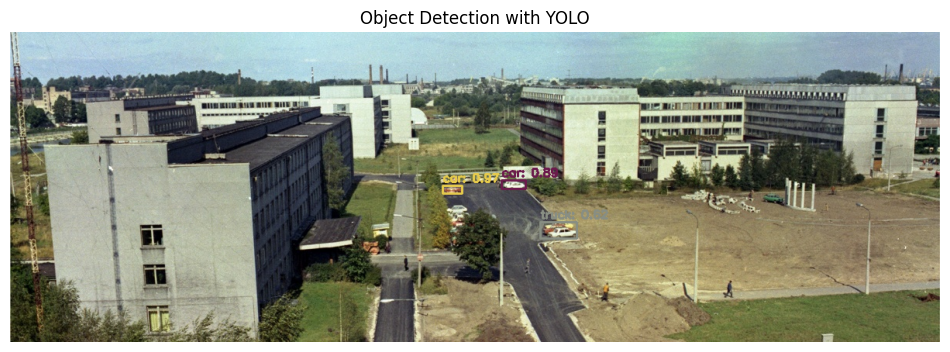

In [2]:
import cv2
import numpy as np
import requests
import matplotlib.pyplot as plt

# Image URL
url = "https://www.rtu.lv/writable/public_files/m_RTU_b_rtu_kipsala_etf.jpg"
image_path = "/content/m_RTU_b_rtu_kipsala_etf.jpg" # Corrected path to local file

# --- 1. Download the image ---
print("Downloading image...")
try:
    response = requests.get(url, stream=True)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
    image_array = np.asarray(bytearray(response.content), dtype="uint8")
    image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
    if image is None:
        raise ValueError("Could not decode image from URL.")
    print("Image downloaded successfully.")
except requests.exceptions.RequestException as e:
    print(f"Error downloading image from URL: {e}")
    image = None
except ValueError as e:
    print(f"Error processing image from URL: {e}")
    image = None

if image is None:
    print(f"Attempting to load image from local path: {image_path}")
    try:
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError("Could not load image from local path.")
        print("Image loaded from local path successfully.")
    except Exception as e:
        print(f"Error loading image from local path: {e}")
        image = None

if image is None:
    print("Failed to load image. Please check the URL, local path, or your internet connection.")
else:
    # Get image dimensions
    (H, W) = image.shape[:2]

    # --- 2. Load YOLO model ---
    # Download YOLO files if not present. -nc ensures it only downloads if file doesn't exist.
    print("Downloading YOLO model files (if not already present)...")
    !wget -nc https://pjreddie.com/media/files/yolov3.weights
    !wget -nc https://github.com/pjreddie/darknet/blob/master/cfg/yolov3.cfg?raw=true -O yolov3.cfg
    !wget -nc https://github.com/pjreddie/darknet/blob/master/data/coco.names?raw=true -O coco.names

    print("Loading YOLO model...")
    net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")

    # Get the names of the output layers
    output_layers = [layer_name for layer_name in net.getUnconnectedOutLayersNames()]

    # Load COCO class labels
    with open("coco.names", "r") as f:
        classes = [line.strip() for line in f.readlines()]

    # --- 3. Pre-process image and run detection ---
    # Create a blob from the image and set the input for the neural network
    blob = cv2.dnn.blobFromImage(image, 1/255.0, (416, 416), swapRB=True, crop=False)
    net.setInput(blob)

    # Perform a forward pass and get the outputs from the output layers
    layer_outputs = net.forward(output_layers)

    # --- 4. Process detection outputs ---
    boxes = []
    confidences = []
    class_ids = []

    # Loop over each of the layer outputs
    for output in layer_outputs:
        # Loop over each of the detections
        for detection in output:
            # Extract the class ID and confidence (probability) of the current object detection
            scores = detection[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]

            # Filter out weak predictions by ensuring the detected probability is greater than the minimum probability
            if confidence > 0.5: # Confidence threshold
                # Scale the bounding box coordinates back to the original image size
                box = detection[0:4] * np.array([W, H, W, H])
                (centerX, centerY, width, height) = box.astype("int")

                # Use the center (x, y)-coordinates to derive the top and left corner of the bounding box
                x = int(centerX - (width / 2))
                y = int(centerY - (height / 2))

                # Update our list of bounding box rectangles, confidences, and class IDs
                boxes.append([x, y, int(width), int(height)])
                confidences.append(float(confidence))
                class_ids.append(class_id)

    # Apply non-maxima suppression to suppress weak, overlapping bounding boxes
    idxs = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.3) # Confidence threshold, NMS threshold

    # --- 5. Draw bounding boxes and labels ---
    # Ensure at least one detection exists
    if len(idxs) > 0:
        # Loop over the indexes we are keeping
        for i in idxs.flatten():
            # Extract the bounding box coordinates
            (x, y) = (boxes[i][0], boxes[i][1])
            (w, h) = (boxes[i][2], boxes[i][3])

            # Draw a bounding box rectangle and label on the image
            color = [int(c) for c in np.random.uniform(0, 255, size=3)]
            cv2.rectangle(image, (x, y), (x + w, y + h), color, 2)
            text = f"{classes[class_ids[i]]}: {confidences[i]:.2f}"
            cv2.putText(image, text, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    # --- 6. Display the result ---
    plt.figure(figsize=(12, 10))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
    plt.title("Object Detection with YOLO")
    plt.axis("off")
    plt.show()

In [ ]:
## TODO challenge for students improve object detection on this image
# hint use better models, maybe even adjust settings

In [ ]:
## TODO generate an AI image of correct clock with 2:13 in the afternoon :)
# Probably solved in 2027, maybe